## 结果比较
要比较的模型：  
### bpe：  
1. 默认参数的模型 fine_tuned_model_D ✅
2. 加载MLM预训练参数的模型 fine_tuned_model_P ✅
### base：  
1. 默认参数的模型 fine_tuned_model_D ✅
2. 加载MLM预训练参数的模型 fine_tuned_model_P ✅
### two_tower: 
1. 默认参数模型 imotifTower_3D8H256D_D ✅
2. 加载MLM预训练参数的模型，但没设置 cross-attention 的参数 imotifTower_3D8H256D_MLM ✅
3. 加载MLM预训练参数的模型，加载并设置全部参数 imotifTower_3D8H256D_MLMA ✅
4. 加载base和bpe精调模型的参数的模型，但没设置 cross-attention 的参数 imotifTower_3D8H256D_P3 ✅
5. 加载base和bpe精调模型的参数的模型，加载并设置全部参数 imotifTower_3D8H256D_P4 ✅
6. 基于编号3模型进一步半监督学习的模型，在之前的数据上额外加 imotifTower_3D8H256D_semi_v1 ✅
7. 基于编号3模型进一步半监督学习的模型，用伪标签正例补充正例，不重复生成正例 imotifTower_3D8H256D_semi_v2 ✅
### retrained_seeker:
Accuracy: 0.7865497076023392
Cross-Entropy Loss: 0.4856150731453027
Cross-Entropy Loss: 0.6006501913070679
AUROC: 0.8819901382254176
AUPRC: 0.879701536392667
Precision: 0.8834714773281326
Recall: 0.6610726012404232
F1-score: 0.7562604340567612

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.4856150731453027, 0.3188956677913666, 0.3046659529209137, 0.3015376329421997, 0.29628708958625793, 0.28380945324897766, 0.2999214231967926, 0.2910363972187042, 0.25956016778945923, 0.2597007155418396, 0.25155606865882874, 0.22847771644592285]


<Figure size 800x600 with 0 Axes>

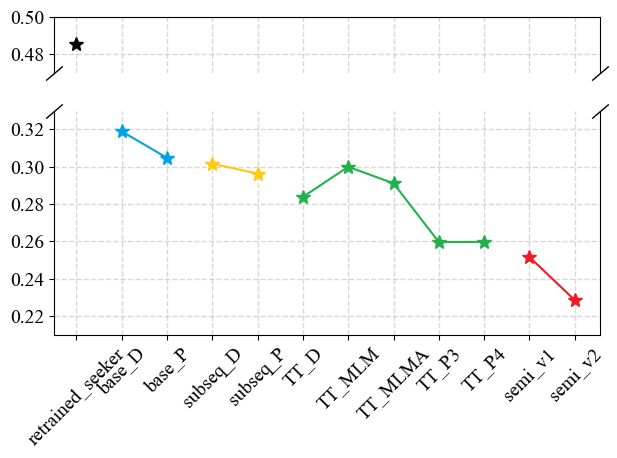

In [8]:
#best_model_eval_metrics.txt format: {'eval_loss': 0.28380945324897766, 'eval_accuracy': 0.9183078045222466, 'eval_auroc': 0.966364321697601, 'eval_auprc': 0.9702966557443437, 'eval_recall': 0.9197665937272064, 'eval_precision': 0.9170909090909091, 'eval_f1': 0.9184268026219956, 'eval_runtime': 0.7548, 'eval_samples_per_second': 7265.103, 'eval_steps_per_second': 14.573, 'epoch': 100.0}
'''
从各个模型目录下的best_model_eval_metrics.txt文件中读取模型评估指标，然后将这些指标画到图中
'''

import sys

sys.path.append("../")
from utils.parameters import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator

model_paths = [os.path.join("..", "train_from_base", "content", "imotifBERT", "fine_tuned_model_D"),
               os.path.join("..", "train_from_base", "content", "imotifBERT", "fine_tuned_model_P"),
               os.path.join("..", "train_from_bpe", "content", "imotifBERT_4L8HT2", "fine_tuned_model_D"),
               os.path.join("..", "train_from_bpe", "content", "imotifBERT_4L8HT2", "fine_tuned_model_P"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_3D8H256D_D"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_3D8H256D_MLM"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_3D8H256D_MLMA"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_3D8H256D_P3"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_3D8H256D_P4"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_semi_v1"),
               os.path.join("..", "train_two_tower_model", "content", "imotifTower_semi_v2"),
]

# 画 eval_loss
eval_loss = [0.4856150731453027] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_loss.append(float(line[0].split(":")[-1]))
print(eval_loss)

plt.rcParams.update({'font.size': 14})
plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [1, 4]})
ax1.plot([0], eval_loss[0], marker="*", markersize=10, color="#000")
ax2.plot([1,2], eval_loss[1:3], marker="*", markersize=10, color="#00A2E8")
ax2.plot([3,4], eval_loss[3:5], marker="*", markersize=10, color="#FFC90E")
ax2.plot([5,6,7,8,9], eval_loss[5:10], marker="*", markersize=10, color="#22B14C")
ax2.plot([10,11], eval_loss[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.02) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.02) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.47, .5)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.21, .33)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_loss.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.7865497076023392, 0.8947848285922684, 0.9004376367614879, 0.8964259664478483, 0.9093727206418672, 0.9183078045222466, 0.9062727935813275, 0.9070021881838074, 0.925419401896426, 0.9290663749088257, 0.9287016776075857, 0.9301604668125456]


<Figure size 800x600 with 0 Axes>

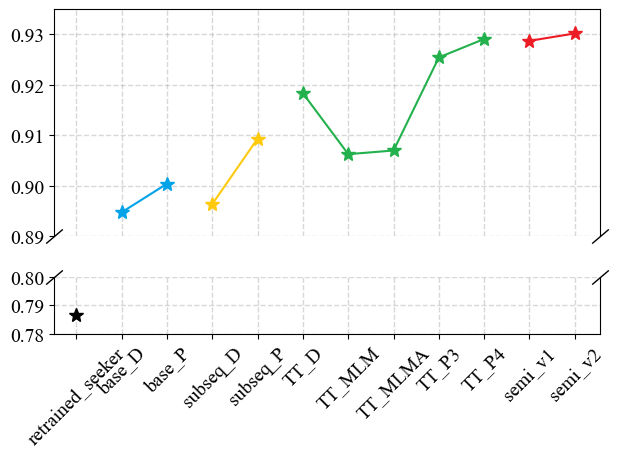

In [9]:
# 画 eval_accuracy
eval_accuracy = [0.7865497076023392] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_accuracy.append(float(line[1].split(":")[-1]))
print(eval_accuracy)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_accuracy[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_accuracy[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_accuracy[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_accuracy[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_accuracy[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.89, .935)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.78, .80)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_acc.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.8834714773281326, 0.9004809470958195, 0.9134036144578314, 0.8890479599141017, 0.9134438305709024, 0.9170909090909091, 0.9092578986039677, 0.9070021881838074, 0.9460803059273423, 0.9533718689788054, 0.936826458565589, 0.9296903460837888]


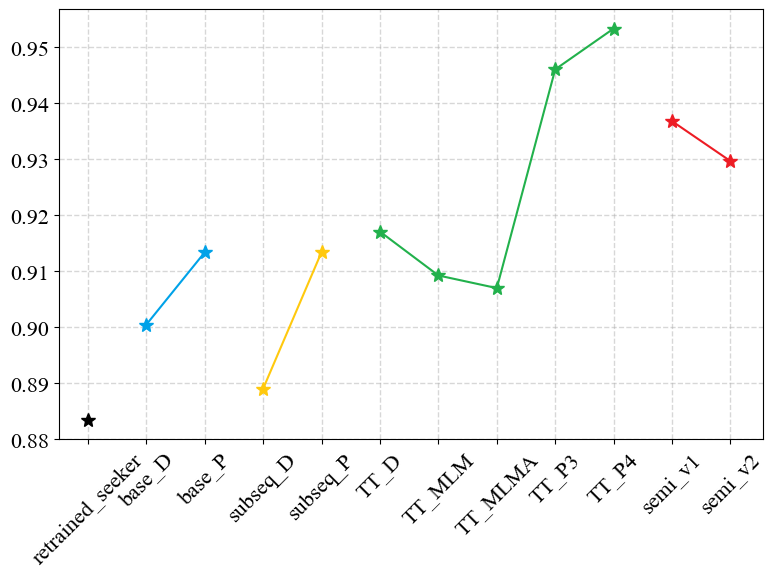

In [10]:
# 画 eval_precision
eval_precision = [0.8834714773281326] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_precision.append(float(line[5].split(":")[-1]))
print(eval_precision)

plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
plt.plot([0], eval_precision[0], marker="*", markersize=10, color="#000")
plt.plot([1,2], eval_precision[1:3], marker="*", markersize=10, color="#00A2E8")
plt.plot([3,4], eval_precision[3:5], marker="*", markersize=10, color="#FFC90E")
plt.plot([5,6,7,8,9], eval_precision[5:10], marker="*", markersize=10, color="#22B14C")
plt.plot([10,11], eval_precision[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(-0.5)

plt.grid(ls='--',alpha=0.5,linewidth=1)

plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_precision.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.6610726012404232, 0.8876732312180889, 0.8847556528081693, 0.9059080962800875, 0.9044493070751276, 0.9197665937272064, 0.9026258205689278, 0.9070021881838074, 0.9022611232676878, 0.9022611232676878, 0.9194018964259665, 0.9307075127644056]


<Figure size 800x600 with 0 Axes>

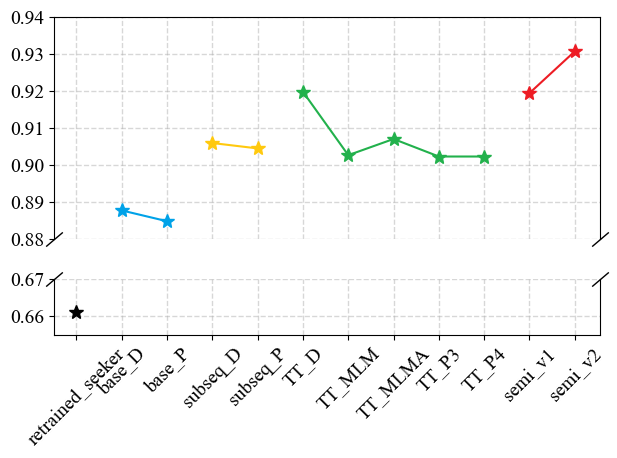

In [11]:
# 画 eval_recall
eval_recall = [0.6610726012404232] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_recall.append(float(line[4].split(":")[-1]))
print(eval_recall)

plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_recall[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_recall[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_recall[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_recall[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_recall[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.88, .94)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.655, .67)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_recall.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.7562604340567612, 0.8940312213039486, 0.8988514264542423, 0.8973988439306358, 0.9089243173905076, 0.9184268026219956, 0.9059297218155198, 0.9070021881838074, 0.9236512973679298, 0.9271126100805696, 0.9280323946254372, 0.9301986513577547]


<Figure size 800x600 with 0 Axes>

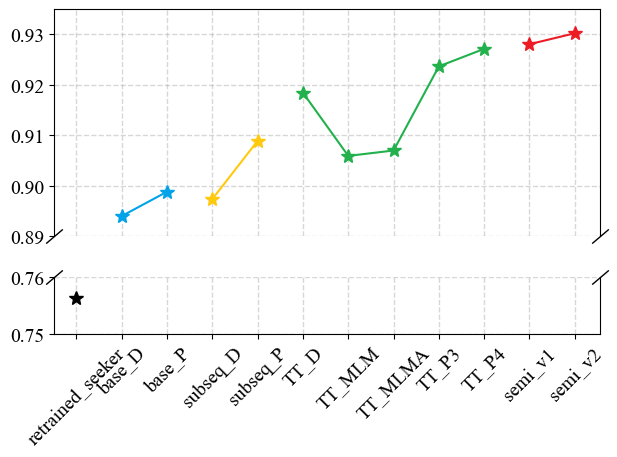

In [12]:
# 画 eval_f1
eval_f1 = [0.7562604340567612] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_f1.append(float(line[6].split(":")[-1]))
print(eval_f1)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_f1[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_f1[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_f1[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_f1[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_f1[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.89, .935)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.75, .76)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_f1.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.8819901382254176, 0.9528191819608105, 0.9603307892304966, 0.9530753478988807, 0.96199393926819, 0.966364321697601, 0.9644708750234753, 0.9654125442039196, 0.9760546029800372, 0.9776174014080348, 0.9775180473292507, 0.978557474539021]


<Figure size 800x600 with 0 Axes>

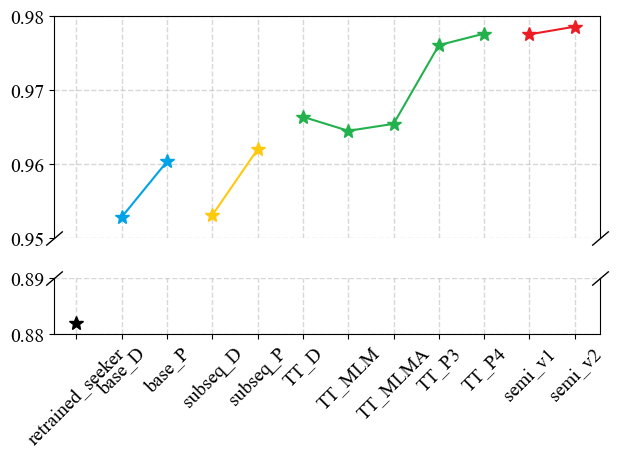

In [13]:
# 画 eval_auroc
eval_auroc = [0.8819901382254176] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_auroc.append(float(line[2].split(":")[-1]))
print(eval_auroc)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_auroc[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_auroc[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_auroc[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_auroc[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_auroc[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.95, .98)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.88, .89)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_auroc.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.879701536392667, 0.9571329485141862, 0.9633385526288566, 0.955356954671671, 0.964651422387477, 0.9702966557443437, 0.9672889018909059, 0.9678021471684507, 0.9789841985126138, 0.9804843866352851, 0.9802628992679803, 0.9803863761837525]


<Figure size 800x600 with 0 Axes>

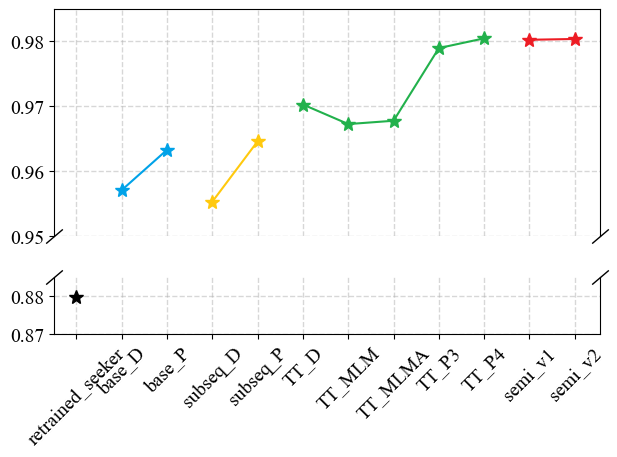

In [14]:
# 画 eval_auprc
eval_auprc = [0.879701536392667] # start with retrained_seeker's metrics
for model_path in model_paths:
    with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
        line = f.readline().strip().split(",")
        eval_auprc.append(float(line[3].split(":")[-1]))
print(eval_auprc)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_auprc[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_auprc[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_auprc[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_auprc[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_auprc[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(len(model_paths) + 1), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.95, .985)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.87, .885)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_auprc.eps", format="eps", bbox_inches="tight")